# DUS vs DUS-S — Benchmarks

Two benchmarks, both using the same fixed sample for both algorithms (seed 42).  
Ray is initialised once before any timing so startup cost is excluded.  
Results are **appended** to their respective CSVs — existing data is never overwritten.

In [ ]:
import sys, os
sys.path.insert(0, '../src')

import csv
import time
from datetime import datetime

import numpy as np
import ray

from generator_multidim import MultidimSampleGenerator
from dus import discover_dus
from dusd import discover_dus_dimension

ALGORITHMS = [
    ('D-U-S',   discover_dus),
    ('D-U-S-D', discover_dus_dimension),
]

In [7]:
# Initialise Ray BEFORE timing so startup overhead is excluded from measurements.
if not ray.is_initialized():
    ray.init(runtime_env={"env_vars": {"PYTHONPATH": os.path.abspath('../src')}})
print("Ray ready:", ray.is_initialized())

Ray ready: True


In [8]:
def run_benchmark(param_name, param_values, fixed_params, algorithms, reps, seed, csv_path):
    """Generic benchmark loop.

    param_name:   the axis being varied ('trace_count' or 'trace_length')
    param_values: list of values to iterate over
    fixed_params: dict with the non-varying generator arguments
    """
    gen = MultidimSampleGenerator()
    run_timestamp = datetime.now().isoformat()

    fieldnames = [
        'run_timestamp', 'algorithm', 'trace_count', 'trace_length',
        'type_count', 'dimensions', 'support', 'rep', 'time_s', 'queries_found',
    ]

    file_exists = os.path.isfile(csv_path)
    with open(csv_path, 'a', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        if not file_exists:
            writer.writeheader()

        for value in param_values:
            params = {**fixed_params, param_name: value}

            # same sample for both algorithms
            np.random.seed(seed)
            sample = gen.generate_random_sample(
                sample_size=params['trace_count'],
                min_trace_length=params['trace_length'],
                max_trace_length=params['trace_length'],
                event_dimension=params['dimensions'],
                type_count=params['type_count'],
            )

            for alg_name, alg_fn in algorithms:
                times = []
                queries_found = None

                for rep in range(1, reps + 1):
                    t0 = time.perf_counter()
                    result = alg_fn(sample=sample, supp=params['support'])
                    elapsed = time.perf_counter() - t0
                    times.append(elapsed)
                    queries_found = len(result.get('queryset', set()))

                    writer.writerow({
                        'run_timestamp': run_timestamp,
                        'algorithm':     alg_name,
                        'trace_count':   params['trace_count'],
                        'trace_length':  params['trace_length'],
                        'type_count':    params['type_count'],
                        'dimensions':    params['dimensions'],
                        'support':       params['support'],
                        'rep':           rep,
                        'time_s':        round(elapsed, 6),
                        'queries_found': queries_found,
                    })
                    f.flush()

                print(f"{param_name}={value:>5}  {alg_name:<10}  "
                      f"mean={np.mean(times):.4f}s  min={min(times):.4f}s  queries={queries_found}")

    print(f"\nSaved to {csv_path}")
    return run_timestamp

---
## Benchmark 1: varying trace count
Fixed: trace length = 10, type count = 5, dimensions = 2, supp = 1.0  
Varying: 2 000 → 50 000 (step 2 000)

In [ ]:
ts_count = run_benchmark(
    param_name='trace_count',
    param_values=list(range(2000, 50001, 2000)),
    fixed_params=dict(trace_length=10, type_count=5, dimensions=2, support=1.0),
    algorithms=ALGORITHMS,
    reps=3,
    seed=42,
    csv_path='dus_trace_count.csv',
)

algorithm       D-U-S   D-U-S-D  speedup (DUS/DUS-D)
trace_count                                         
2000           0.5158    0.6598                 0.78
4000           1.2334    0.9676                 1.27
6000           2.7682    2.2754                 1.22
8000           4.7551    3.9740                 1.20
10000          6.9188    5.4503                 1.27
12000         10.4328    8.0330                 1.30
14000         12.6817   13.0147                 0.97
16000         20.8989   18.3339                 1.14
18000         25.1600   19.5258                 1.29
20000         29.1856   27.1643                 1.07
22000         41.4822   33.2844                 1.25
24000         42.9925   36.8954                 1.17
26000         48.6659   42.1216                 1.16
28000         55.6796   47.5740                 1.17
30000         67.8487   55.2439                 1.23
32000         63.6833   53.9432                 1.18
34000         86.2823   71.3749               

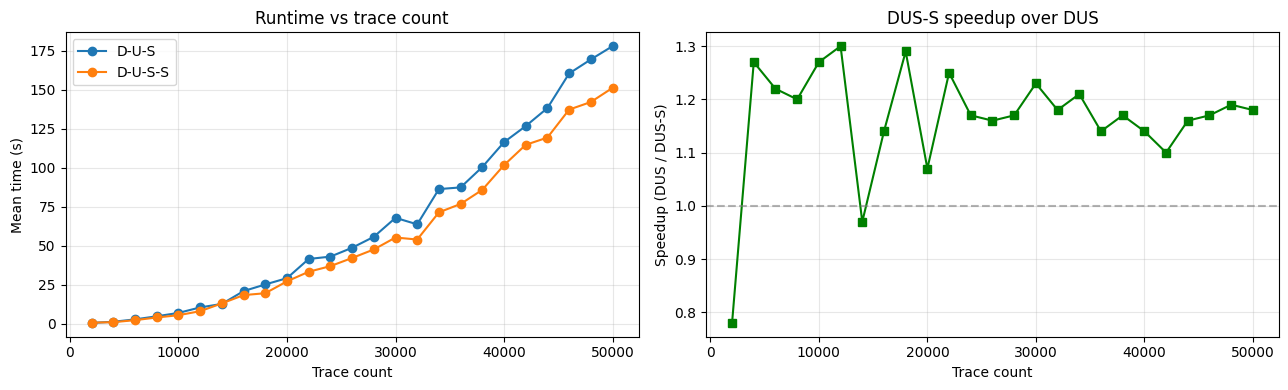

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('dus_trace_count.csv')
df_run = df#[df['run_timestamp'] == ts_count]

summary = (
    df_run.groupby(['algorithm', 'trace_count'])['time_s']
    .mean().unstack('algorithm').round(4)
)
summary['speedup (DUS/DUS-D)'] = (summary['D-U-S'] / summary['D-U-S-D']).round(2)
print(summary.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for alg, grp in df_run.groupby('algorithm'):
    means = grp.groupby('trace_count')['time_s'].mean()
    axes[0].plot(means.index, means.values, marker='o', label=alg)
axes[0].set_xlabel('Trace count'); axes[0].set_ylabel('Mean time (s)')
axes[0].set_title('Runtime vs trace count'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(summary.index, summary['speedup (DUS/DUS-D)'], marker='s', color='green')
axes[1].axhline(1.0, linestyle='--', color='grey', alpha=0.6)
axes[1].set_xlabel('Trace count'); axes[1].set_ylabel('Speedup (DUS / DUS-S)')
axes[1].set_title('DUS-S speedup over DUS'); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('benchmark_dus_trace_count.png', dpi=150)
plt.show()

---
## Benchmark 2: varying trace length
Fixed: trace count = 10 000, type count = 5, dimensions = 2, supp = 1.0  
Varying: trace length 1 → 12

In [12]:
ts_length = run_benchmark(
    param_name='trace_length',
    param_values=list(range(1, 13)),
    fixed_params=dict(trace_count=10000, type_count=5, dimensions=2, support=1.0),
    algorithms=ALGORITHMS,
    reps=3,
    seed=42,
    csv_path='benchmark_dus_trace_length.csv',
)

trace_length=    1  D-U-S       mean=0.0391s  min=0.0110s  queries=0
trace_length=    1  D-U-S-D     mean=0.0613s  min=0.0518s  queries=0
trace_length=    2  D-U-S       mean=0.5911s  min=0.5510s  queries=0
trace_length=    2  D-U-S-D     mean=0.3631s  min=0.3542s  queries=0
trace_length=    3  D-U-S       mean=1.3261s  min=0.5552s  queries=0
trace_length=    3  D-U-S-D     mean=0.3834s  min=0.3693s  queries=0
trace_length=    4  D-U-S       mean=0.5945s  min=0.5517s  queries=0
trace_length=    4  D-U-S-D     mean=0.4861s  min=0.4060s  queries=0
trace_length=    5  D-U-S       mean=0.6891s  min=0.5586s  queries=0
trace_length=    5  D-U-S-D     mean=0.4192s  min=0.4056s  queries=0
trace_length=    6  D-U-S       mean=4.8623s  min=4.7036s  queries=2
trace_length=    6  D-U-S-D     mean=3.5727s  min=3.5499s  queries=2
trace_length=    7  D-U-S       mean=5.6033s  min=5.4832s  queries=2
trace_length=    7  D-U-S-D     mean=4.7651s  min=4.4168s  queries=2
trace_length=    8  D-U-S       me

algorithm       D-U-S  D-U-S-D  speedup (DUS/DUS-D)
trace_length                                       
1              0.0391   0.0613                 0.64
2              0.5911   0.3631                 1.63
3              1.3261   0.3834                 3.46
4              0.5945   0.4861                 1.22
5              0.6891   0.4192                 1.64
6              4.8623   3.5727                 1.36
7              5.6033   4.7651                 1.18
8              5.9645   5.0892                 1.17
9              6.5706   5.1667                 1.27
10             8.5583   8.3496                 1.02
11            22.7213  20.3736                 1.12
12            36.6755  33.8081                 1.08


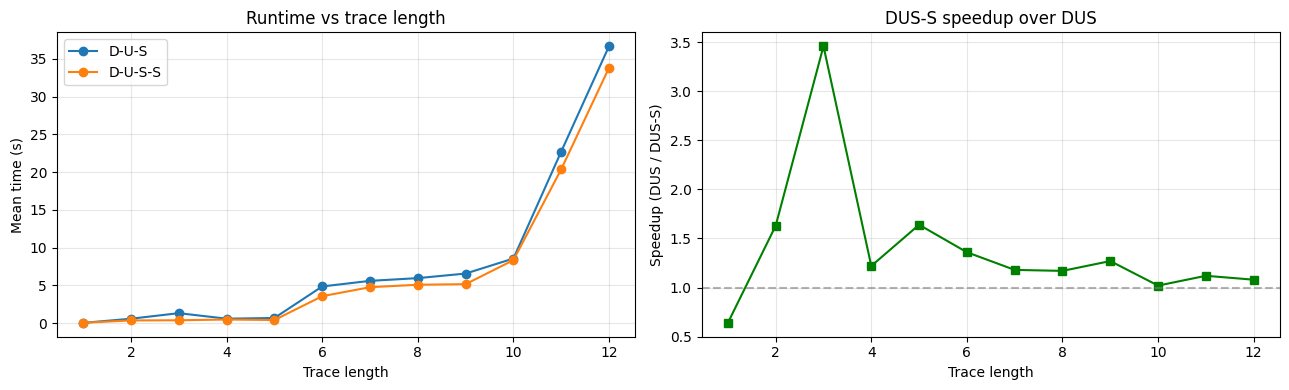

In [15]:
df2 = pd.read_csv('benchmark_dus_trace_length.csv')
df2_run = df2[df2['run_timestamp'] == ts_length]

summary2 = (
    df2_run.groupby(['algorithm', 'trace_length'])['time_s']
    .mean().unstack('algorithm').round(4)
)
summary2['speedup (DUS/DUS-D)'] = (summary2['D-U-S'] / summary2['D-U-S-D']).round(2)
print(summary2.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for alg, grp in df2_run.groupby('algorithm'):
    means = grp.groupby('trace_length')['time_s'].mean()
    axes[0].plot(means.index, means.values, marker='o', label=alg)
axes[0].set_xlabel('Trace length'); axes[0].set_ylabel('Mean time (s)')
axes[0].set_title('Runtime vs trace length'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(summary2.index, summary2['speedup (DUS/DUS-D)'], marker='s', color='green')
axes[1].axhline(1.0, linestyle='--', color='grey', alpha=0.6)
axes[1].set_xlabel('Trace length'); axes[1].set_ylabel('Speedup (DUS / DUS-S)')
axes[1].set_title('DUS-S speedup over DUS'); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('benchmark_dus_trace_length.png', dpi=150)
plt.show()

---
## Benchmark 3: varying dimensions
Fixed: trace count = 10 000, trace length = 10, type count = 5, supp = 1.0  
Varying: dimensions 1 → 5

In [19]:
ts_dims = run_benchmark(
    param_name='dimensions',
    param_values=list(range(5, 6)),
    fixed_params=dict(trace_count=10000, trace_length=10, type_count=5, support=1.0),
    algorithms=ALGORITHMS,
    reps=3,
    seed=42,
    csv_path='benchmark_dus_dimensions.csv',
)

dimensions=    5  D-U-S       mean=6147.8407s  min=5514.3752s  queries=5
dimensions=    5  D-U-S-D     mean=5800.2317s  min=5662.4690s  queries=5

Saved to benchmark_dus_dimensions.csv


algorithm       D-U-S    D-U-S-D  speedup (DUS/DUS-D)
dimensions                                           
5           6147.8407  5800.2317                 1.06


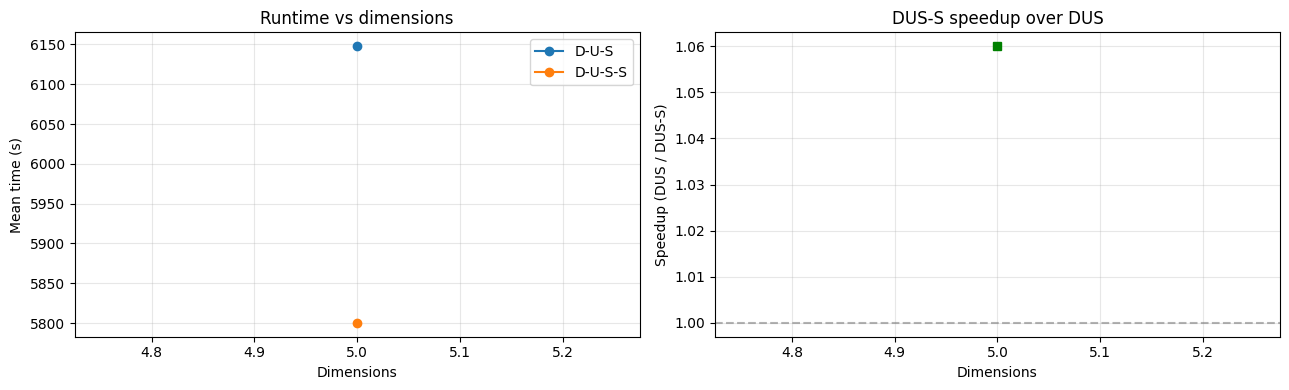

In [20]:
df3 = pd.read_csv('benchmark_dus_dimensions.csv')
df3_run = df3[df3['run_timestamp'] == ts_dims]

summary3 = (
    df3_run.groupby(['algorithm', 'dimensions'])['time_s']
    .mean().unstack('algorithm').round(4)
)
summary3['speedup (DUS/DUS-D)'] = (summary3['D-U-S'] / summary3['D-U-S-D']).round(2)
print(summary3.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for alg, grp in df3_run.groupby('algorithm'):
    means = grp.groupby('dimensions')['time_s'].mean()
    axes[0].plot(means.index, means.values, marker='o', label=alg)
axes[0].set_xlabel('Dimensions'); axes[0].set_ylabel('Mean time (s)')
axes[0].set_title('Runtime vs dimensions'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(summary3.index, summary3['speedup (DUS/DUS-D)'], marker='s', color='green')
axes[1].axhline(1.0, linestyle='--', color='grey', alpha=0.6)
axes[1].set_xlabel('Dimensions'); axes[1].set_ylabel('Speedup (DUS / DUS-S)')
axes[1].set_title('DUS-S speedup over DUS'); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('benchmark_dus_dimensions.png', dpi=150)
plt.show()



---
## Benchmark 4: varying type count
Fixed: trace count = 10 000, trace length = 10, dimensions = 2, supp = 1.0  
Varying: type count 3 → 12

In [21]:
ts_types = run_benchmark(
    param_name='type_count',
    param_values=list(range(3, 13)),
    fixed_params=dict(trace_count=10000, trace_length=10, dimensions=2, support=1.0),
    algorithms=ALGORITHMS,
    reps=3,
    seed=42,
    csv_path='benchmark_dus_type_count.csv',
)

type_count=    3  D-U-S       mean=710.3077s  min=685.1424s  queries=10
type_count=    3  D-U-S-D     mean=691.7314s  min=677.2499s  queries=10
type_count=    4  D-U-S       mean=101.3574s  min=94.1653s  queries=8
type_count=    4  D-U-S-D     mean=112.0920s  min=101.4893s  queries=8
type_count=    5  D-U-S       mean=7.9635s  min=7.4821s  queries=2
type_count=    5  D-U-S-D     mean=8.3324s  min=6.7780s  queries=2
type_count=    6  D-U-S       mean=8.4022s  min=7.5701s  queries=2
type_count=    6  D-U-S-D     mean=6.5632s  min=6.4261s  queries=2
type_count=    7  D-U-S       mean=9.2809s  min=8.1350s  queries=2
type_count=    7  D-U-S-D     mean=8.0055s  min=7.4971s  queries=2
type_count=    8  D-U-S       mean=8.0346s  min=6.5035s  queries=2
type_count=    8  D-U-S-D     mean=6.4347s  min=6.2008s  queries=2
type_count=    9  D-U-S       mean=8.4505s  min=7.1858s  queries=2
type_count=    9  D-U-S-D     mean=6.5183s  min=5.8905s  queries=2
type_count=   10  D-U-S       mean=0.9394s  m

In [ ]:
df4 = pd.read_csv('benchmark_dus_type_count.csv')
df4_run = df4[df4['run_timestamp'] == ts_types]

summary4 = (
    df4_run.groupby(['algorithm', 'type_count'])['time_s']
    .mean().unstack('algorithm').round(4)
)
summary4['speedup (DUS/DUS-D)'] = (summary4['D-U-S'] / summary4['D-U-S-D']).round(2)
print(summary4.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for alg, grp in df4_run.groupby('algorithm'):
    means = grp.groupby('type_count')['time_s'].mean()
    axes[0].plot(means.index, means.values, marker='o', label=alg)
axes[0].set_xlabel('Type count'); axes[0].set_ylabel('Mean time (s)')
axes[0].set_title('Runtime vs type count'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(summary4.index, summary4['speedup (DUS/DUS-D)'], marker='s', color='green')
axes[1].axhline(1.0, linestyle='--', color='grey', alpha=0.6)
axes[1].set_xlabel('Type count'); axes[1].set_ylabel('Speedup (DUS / DUS-S)')
axes[1].set_title('DUS-S speedup over DUS'); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('benchmark_dus_type_count.png', dpi=150)
plt.show()